# MAESTRO Dataset Exploration

In [1]:
from pathlib import Path
from collections import Counter
import json
import random
import statistics

import numpy as np

ROOT = Path.cwd().resolve().parent
if not (ROOT / "data").exists():
    ROOT = Path.cwd().resolve()

DATA_DIR = ROOT / "data" / "maestro-v3.0.0"
META_PATH = DATA_DIR / "maestro-v3.0.0.json"

print("Repo root:", ROOT)
print("Data dir exists:", DATA_DIR.exists())
print("Metadata path exists:", META_PATH.exists())

Repo root: /Users/beatriceghosn/Downloads/Junior Sem2/CS372/RoboComposer
Data dir exists: True
Metadata path exists: True


## Load MAESTRO Metadata

In [2]:
with open(META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)

columns = list(meta.keys())
n_rows = len(next(iter(meta.values())))
print("Columns:", columns)
print("Rows:", n_rows)

def row_at(i: int) -> dict:
    key = str(i)
    return {col: meta[col].get(key) for col in columns}

print("\nExample row:")
print(row_at(0))

Columns: ['canonical_composer', 'canonical_title', 'split', 'year', 'midi_filename', 'audio_filename', 'duration']
Rows: 1276

Example row:
{'canonical_composer': 'Alban Berg', 'canonical_title': 'Sonata Op. 1', 'split': 'train', 'year': 2018, 'midi_filename': '2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R3_2018_wav--1.midi', 'audio_filename': '2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R3_2018_wav--1.wav', 'duration': 698.661160312}


## Split Distribution

In [3]:
split_counts = Counter(meta["split"].values())
total = sum(split_counts.values())

for split_name in sorted(split_counts):
    count = split_counts[split_name]
    pct = 100.0 * count / total
    print(f"{split_name:>10}: {count:4d} ({pct:5.2f}%)")

      test:  177 (13.87%)
     train:  962 (75.39%)
validation:  137 (10.74%)


## Year Distribution

In [4]:
year_counts = Counter(meta["year"].values())
years = sorted(year_counts)

print("Year range:", min(years), "to", max(years))
print("\nCounts by year:")
for y in years:
    print(f"{y}: {year_counts[y]}")

Year range: 2004 to 2018

Counts by year:
2004: 132
2006: 115
2008: 147
2009: 125
2011: 163
2013: 127
2014: 105
2015: 129
2017: 140
2018: 93


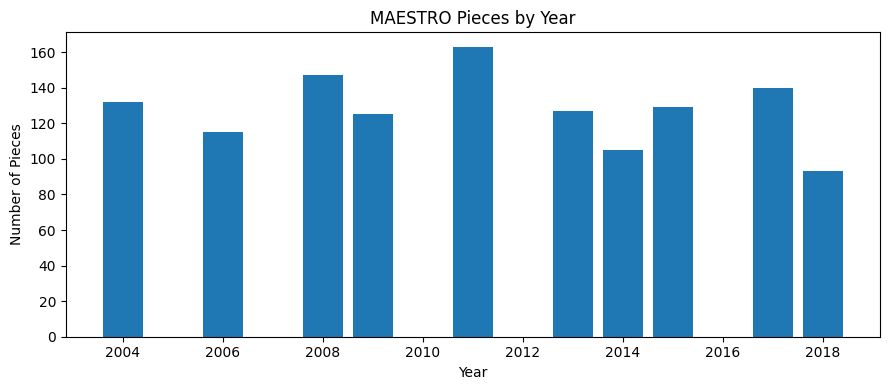

In [5]:
try:
    import matplotlib.pyplot as plt

    xs = sorted(year_counts)
    ys = [year_counts[x] for x in xs]

    plt.figure(figsize=(9, 4))
    plt.bar(xs, ys)
    plt.title("MAESTRO Pieces by Year")
    plt.xlabel("Year")
    plt.ylabel("Number of Pieces")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Matplotlib plot skipped:", e)

## Top Composers

In [6]:
composer_counts = Counter(meta["canonical_composer"].values())
top_k = 20
top_composers = composer_counts.most_common(top_k)

print(f"Top {top_k} composers by piece count:\n")
for name, count in top_composers:
    print(f"{count:4d}  {name}")

Top 20 composers by piece count:

 201  Frédéric Chopin
 186  Franz Schubert
 146  Ludwig van Beethoven
 145  Johann Sebastian Bach
 131  Franz Liszt
  59  Sergei Rachmaninoff
  49  Robert Schumann
  45  Claude Debussy
  40  Joseph Haydn
  38  Wolfgang Amadeus Mozart
  35  Alexander Scriabin
  31  Domenico Scarlatti
  28  Felix Mendelssohn
  26  Johannes Brahms
  10  Franz Schubert / Franz Liszt
   7  Isaac Albéniz
   6  Modest Mussorgsky
   6  Muzio Clementi
   6  Pyotr Ilyich Tchaikovsky
   6  Pyotr Ilyich Tchaikovsky / Mikhail Pletnev


## Inspect Files Through `MIDIDataset`

In [7]:
import sys

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.midi_dataset import MIDIDataset

dataset = MIDIDataset(raw_dir=str(DATA_DIR), max_seq_len=1024)
print("MIDI files discovered by MIDIDataset:", len(dataset))
print("First 3 files:")
for p in dataset.files[:3]:
    print(" -", p)

MIDI files discovered by MIDIDataset: 1276
First 3 files:
 - /Users/beatriceghosn/Downloads/Junior Sem2/CS372/RoboComposer/data/maestro-v3.0.0/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_05_Track05_wav.midi
 - /Users/beatriceghosn/Downloads/Junior Sem2/CS372/RoboComposer/data/maestro-v3.0.0/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_06_Track06_wav.midi
 - /Users/beatriceghosn/Downloads/Junior Sem2/CS372/RoboComposer/data/maestro-v3.0.0/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.midi


## Sample Musical Metadata Summary

We sample a subset of files and run `extract_metadata` to estimate musical-property distributions.

In [8]:
sample_size = min(200, len(dataset.files))
rng = random.Random(42)
sample_paths = rng.sample(dataset.files, sample_size)

tempi = []
velocities = []
modes = Counter()
failures = 0

for midi_path in sample_paths:
    try:
        md = dataset.extract_metadata(str(midi_path))
        tempi.append(md["tempo"])
        velocities.append(md["avg_velocity"])
        modes[md["mode"]] += 1
    except Exception:
        failures += 1

print(f"Sample size requested: {sample_size}")
print(f"Successful metadata extractions: {len(tempi)}")
print(f"Failures: {failures}")

if tempi:
    print("\nTempo stats (BPM):")
    print(f"  mean={statistics.mean(tempi):.2f}")
    print(f"  median={statistics.median(tempi):.2f}")
    print(f"  min={min(tempi):.2f}")
    print(f"  max={max(tempi):.2f}")

if velocities:
    print("\nAverage velocity stats:")
    print(f"  mean={statistics.mean(velocities):.2f}")
    print(f"  median={statistics.median(velocities):.2f}")
    print(f"  min={min(velocities):.2f}")
    print(f"  max={max(velocities):.2f}")

print("\nMode counts:")
for mode_name, c in modes.most_common():
    print(f"  {mode_name}: {c}")

Sample size requested: 200
Successful metadata extractions: 200
Failures: 0

Tempo stats (BPM):
  mean=204.90
  median=206.54
  min=158.34
  max=243.02

Average velocity stats:
  mean=63.47
  median=63.78
  min=44.04
  max=80.04

Mode counts:
  minor: 168
  major: 32


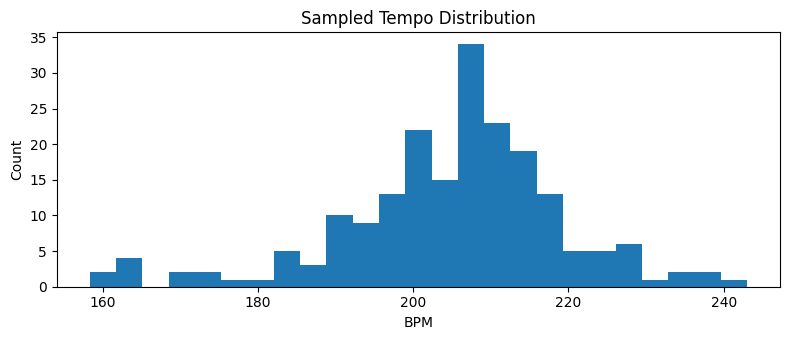

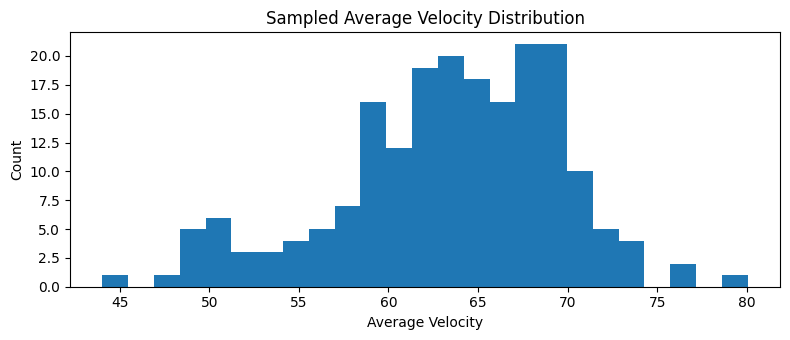

In [9]:
try:
    import matplotlib.pyplot as plt

    if tempi:
        plt.figure(figsize=(8, 3.5))
        plt.hist(tempi, bins=25)
        plt.title("Sampled Tempo Distribution")
        plt.xlabel("BPM")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

    if velocities:
        plt.figure(figsize=(8, 3.5))
        plt.hist(velocities, bins=25)
        plt.title("Sampled Average Velocity Distribution")
        plt.xlabel("Average Velocity")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()
except Exception as e:
    print("Matplotlib plot skipped:", e)

## Quick Notes

- The MAESTRO metadata already includes train/validation/test split labels.
- `MIDIDataset` currently discovers files from folders and can be extended to filter by metadata split.
- This notebook is a starting point for deeper analysis